# `fill_invalid_pores`
Sets every closed or non-spanning pore to `False`. The result is the void space you would actually use for transport simulations.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.fill_invalid_pores)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], axis=None, conn: Literal['max', 'min'] = 'min')>

## `im`
A boolean image with `True` indicating the void phase. The function returns a copy of `im` with all invalid (closed or surface) pores set to `False`.

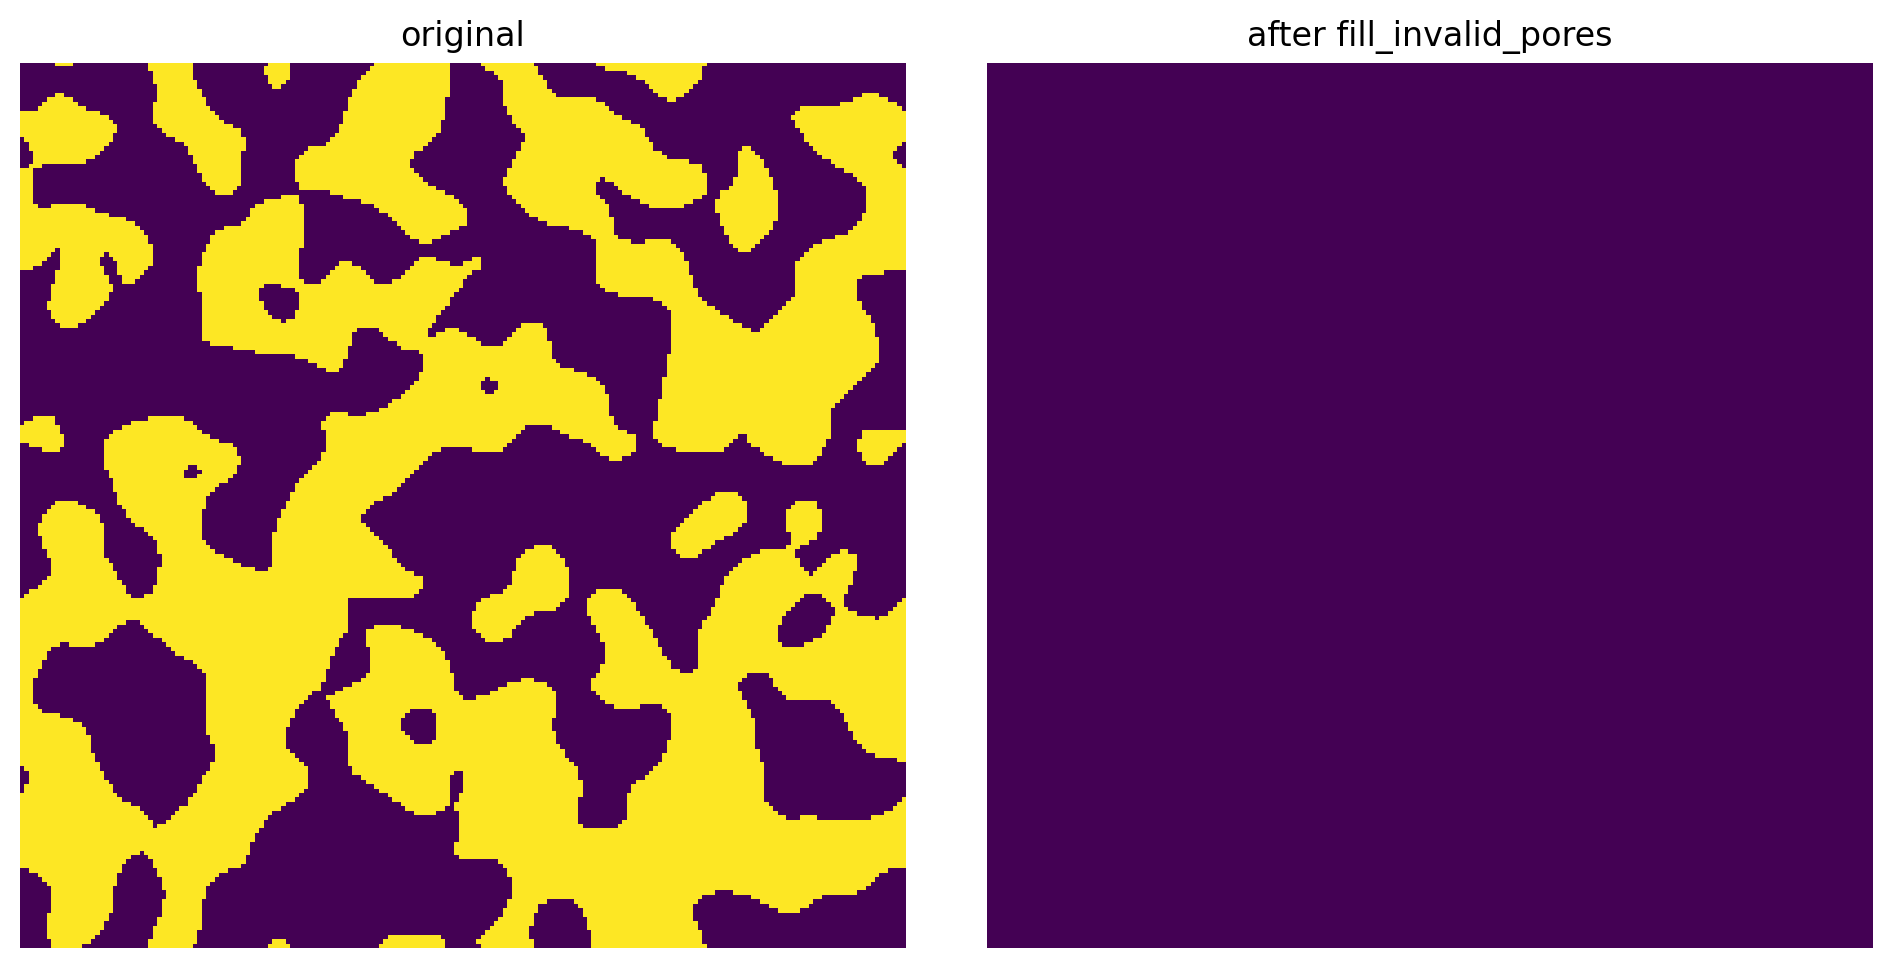

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.5, seed=0)
filled = ps.filters.fill_invalid_pores(im=im.copy())

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
ax[1].imshow(filled, origin='lower', interpolation='none')
ax[1].set_title('after fill_invalid_pores')
ax[1].axis(False);

## `axis`
Restricts the surface-pore test to one direction. Closed pores are always filled; the `axis` argument only changes which surface pores are considered invalid.

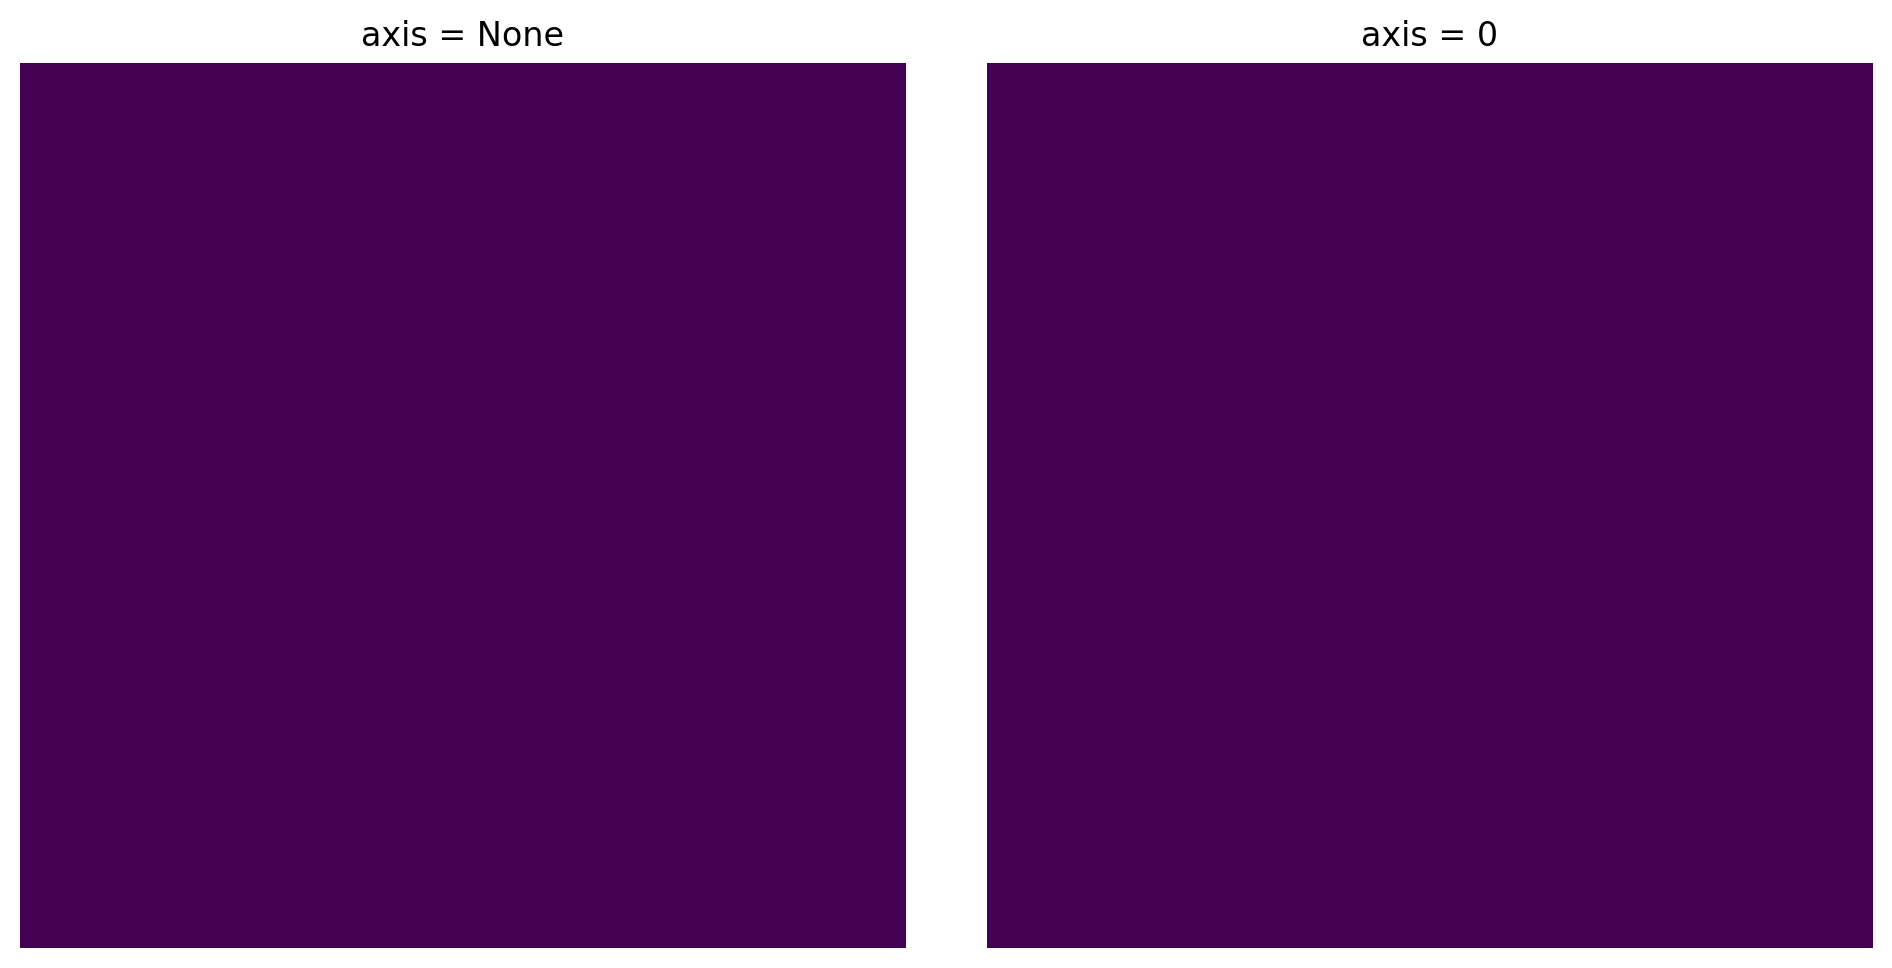

In [4]:
filled_all = ps.filters.fill_invalid_pores(im=im.copy())
filled_x = ps.filters.fill_invalid_pores(im=im.copy(), axis=0)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(filled_all, origin='lower', interpolation='none')
ax[0].set_title('axis = None')
ax[0].axis(False)
ax[1].imshow(filled_x, origin='lower', interpolation='none')
ax[1].set_title('axis = 0')
ax[1].axis(False);

## `conn`
Controls voxel connectivity, the same way as for `find_invalid_pores`.

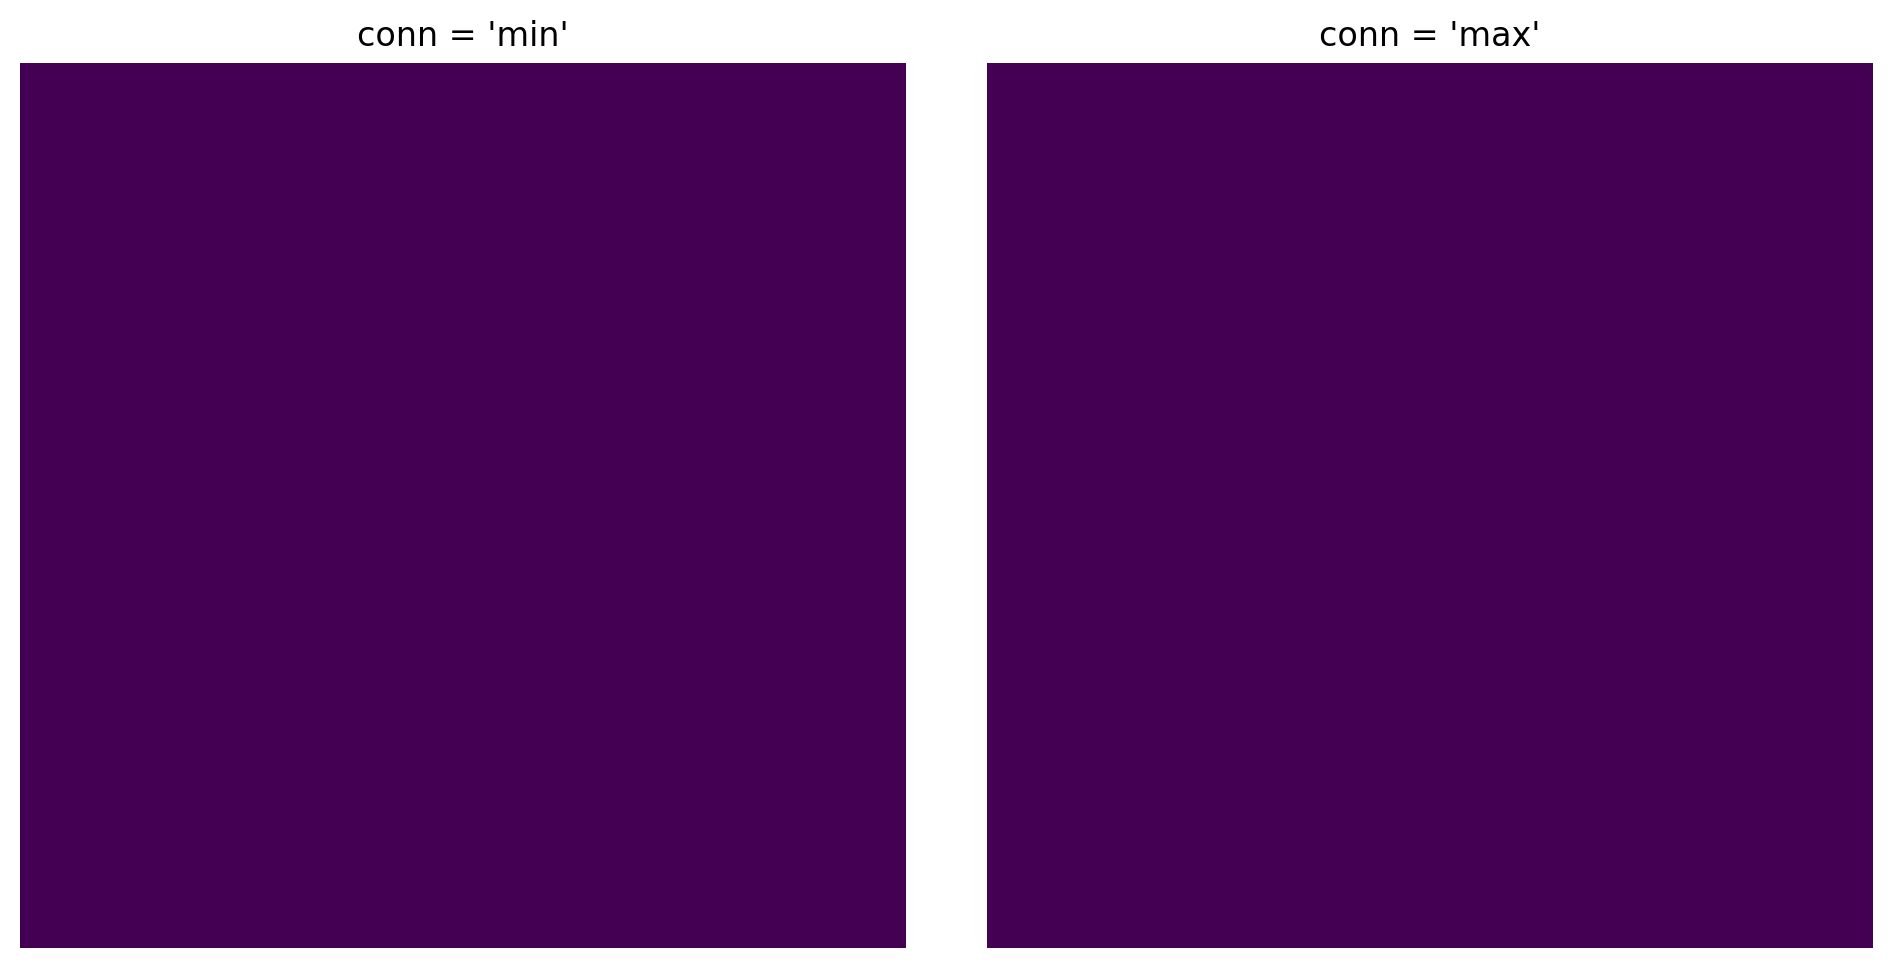

In [5]:
filled_min = ps.filters.fill_invalid_pores(im=im.copy(), conn='min')
filled_max = ps.filters.fill_invalid_pores(im=im.copy(), conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(filled_min, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(filled_max, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);